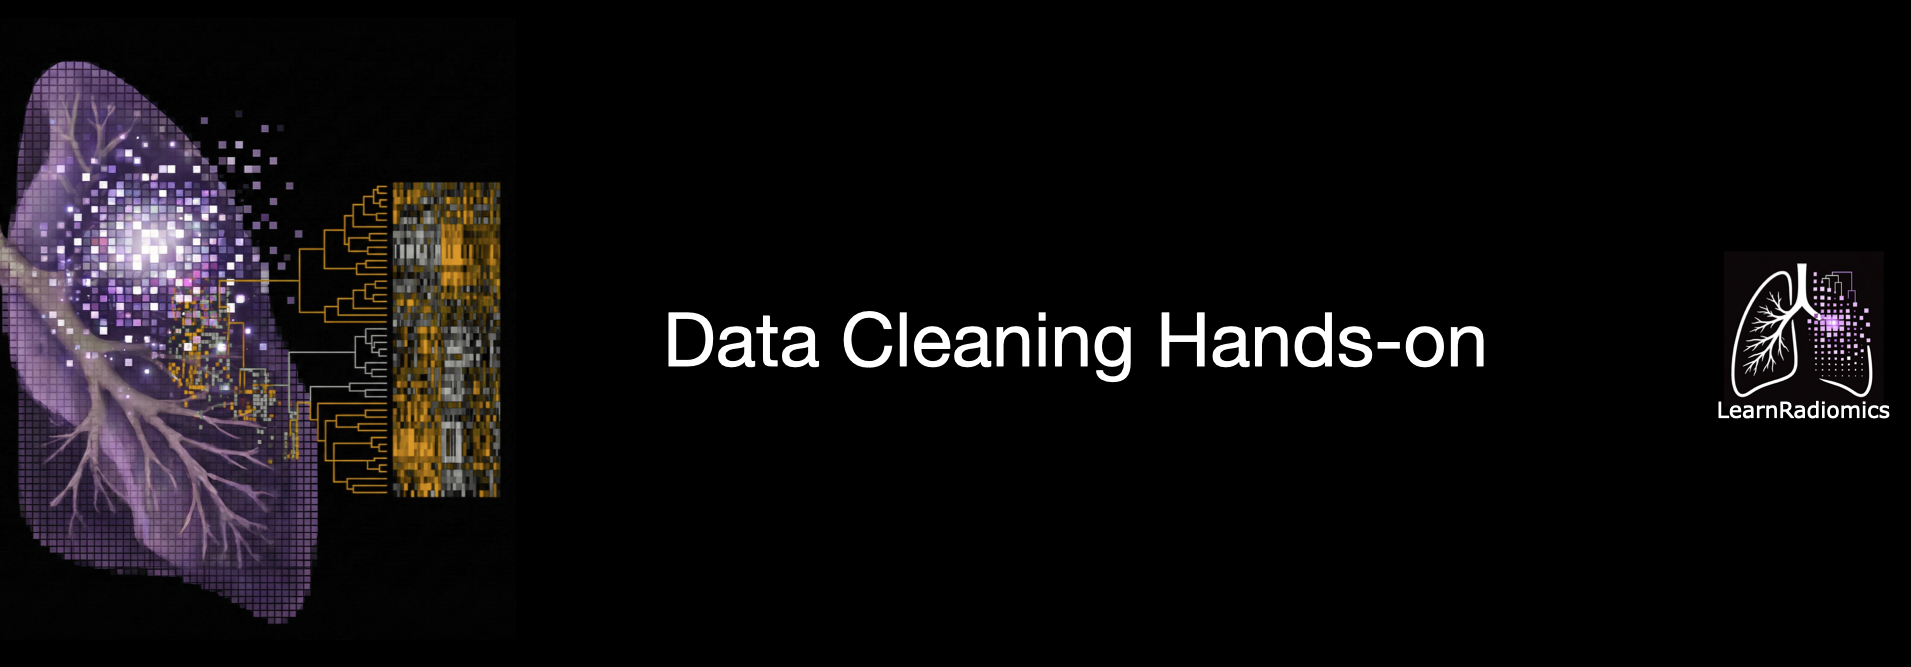

In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import os
from sklearn.impute import SimpleImputer ,KNNImputer

## Suppress warnings
import warnings
warnings.filterwarnings ('ignore')

pd .set_option ('display.max_columns',None )
pd .set_option ('display.max_rows',None )

In [ ]:
url ='https://raw.githubusercontent.com/learnradiomics/data_wrangling/main/data_radiomics.xlsx'

data = pd.read_excel(url)
data.shape

In [ ]:
data.head(3)

### Search for missing values

In [ ]:
data.isnull().sum()

In [ ]:
## Elimination of unnecesary features

data = data.drop(columns =['Date of Death','Time to Death (days)','Date of Last Known Alive'])
data.head(5)

In [ ]:
### Clinic-pathological data

cp_features =['Patient affiliation','Gender','Ethnicity','Smoking status','Histology',
'Pathological T stage','Histopathological Grade',
'Lymphovascular invasion','EGFR mutation status',
'KRAS mutation status','ALK translocation status','Survival Status']

for var in cp_features:
    print (f"Variable: {var}, unique values: {data[var].unique ()}")
    print (" ")

In [ ]:
##
vars_to_review =['Weight (lbs)','Ethnicity','Pathological T stage','Histopathological Grade','Lymphovascular invasion',
'EGFR mutation status','KRAS mutation status','ALK translocation status']

print (f"Unregistered variables (null) in {vars_to_review [0 ]}: {np .where (data [vars_to_review [0 ]]=='Not Collected')[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [1 ]}: {np .where (data [vars_to_review [1 ]]=='Not Recorded In Database')[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [2 ]}: {np .where (data [vars_to_review [2 ]]=='Not Collected')[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [3 ]}: {np .where (data [vars_to_review [3 ]]=='Not Collected')[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [4 ]}: {np .where (data [vars_to_review [4 ]]=='Not Collected')[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [5 ]}: {np .where (data [vars_to_review [5 ]]=='Not Collected')[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [6 ]}: {np .where ((data [vars_to_review [6 ]]=='Not collected')|(data [vars_to_review [6 ]]=='Unknown'))[0 ].shape [0 ]}")
print (f"Unregistered variables (null) in {vars_to_review [7 ]}: {np .where ((data [vars_to_review [7 ]]=='Not collected')|(data [vars_to_review [6 ]]=='Unknown'))[0 ].shape [0 ]}")



### Value imputation

In [ ]:
### categorical variables
df_categorical = data.loc[:,['Patient affiliation','Gender','Ethnicity','Smoking status','Histology',
'Pathological T stage','Histopathological Grade',
'Lymphovascular invasion','EGFR mutation status',
'KRAS mutation status','ALK translocation status','Survival Status']]

df_categorical.head(3)

In [ ]:
## I separate the numerical clinical variables.

numerical_vars =['Age at Histological Diagnosis','Weight (lbs)']

df_numerical = data.loc[:,numerical_vars]
df_numerical.head (3)

In [ ]:
### radiomics features

df_radiomics_features = data.iloc[:,15:].copy()
df_radiomics_features.head (3)

In [ ]:
### Imputation of Weight (lbs) using the median

df_numerical ['Weight (lbs)'] = df_numerical ['Weight (lbs)'].replace("Not Collected", np.nan)

imputer_median = SimpleImputer(strategy ="median")
df_numerical [['Weight (lbs)']] = imputer_median.fit_transform(df_numerical[['Weight (lbs)']])
df_numerical.head (5)

In [ ]:
### Some categorical variables are imputed using the mode.
### There are variables that could potentially be used as targets (ALK and KRAS), so they are not imputed.

categorical_var =['Ethnicity','Pathological T stage','Histopathological Grade','Lymphovascular invasion',
'EGFR mutation status','KRAS mutation status','ALK translocation status']

df_categorical ['Ethnicity']=df_categorical ['Ethnicity'].replace ('Not Recorded In Database',np .nan )
df_categorical ['Pathological T stage']=df_categorical['Pathological T stage'].replace ('Not Collected',np .nan )
df_categorical ['Histopathological Grade']=df_categorical ['Histopathological Grade'].replace ('Not Collected',np .nan )
df_categorical ['Lymphovascular invasion']=df_categorical ['Lymphovascular invasion'].replace ('Not Collected',np .nan )
#df_categorical['KRAS mutation status']  = df_categorical['KRAS mutation status'].replace('Not collected', np.nan)
#df_categorical['ALK translocation status']  = df_categorical['ALK translocation status'].replace('Not collected', np.nan)


### Mode imputation
cat_imputer = SimpleImputer (strategy = "most_frequent")
df_categorical [categorical_var ] = cat_imputer.fit_transform (df_categorical[categorical_var])
df_categorical.head(5)

In [ ]:
### Imputation for KNN

df_numerical = data.loc[:,numerical_vars]
df_numerical['Weight (lbs)'] = df_numerical['Weight (lbs)'].replace("Not Collected", np.nan )

## K = 5
imputer_knn = KNNImputer (n_neighbors = 5)
knn_matrix = imputer_knn.fit_transform (df_numerical)
df_numericas_knn = pd.DataFrame (knn_matrix ,columns = df_numerical .columns)
df_numericas_knn.head(10)

## Encoding of binary categorical variables

In [ ]:
data.head(3)

In [ ]:
data.Histology.unique()

In [ ]:
### OneHotEncodding: Gender

data['Gender'].unique()

gender_bin = np.where (data['Gender']=='Female', 1.0, 0.0)
gender_bin[0:20]

### Encoding of categorical variables

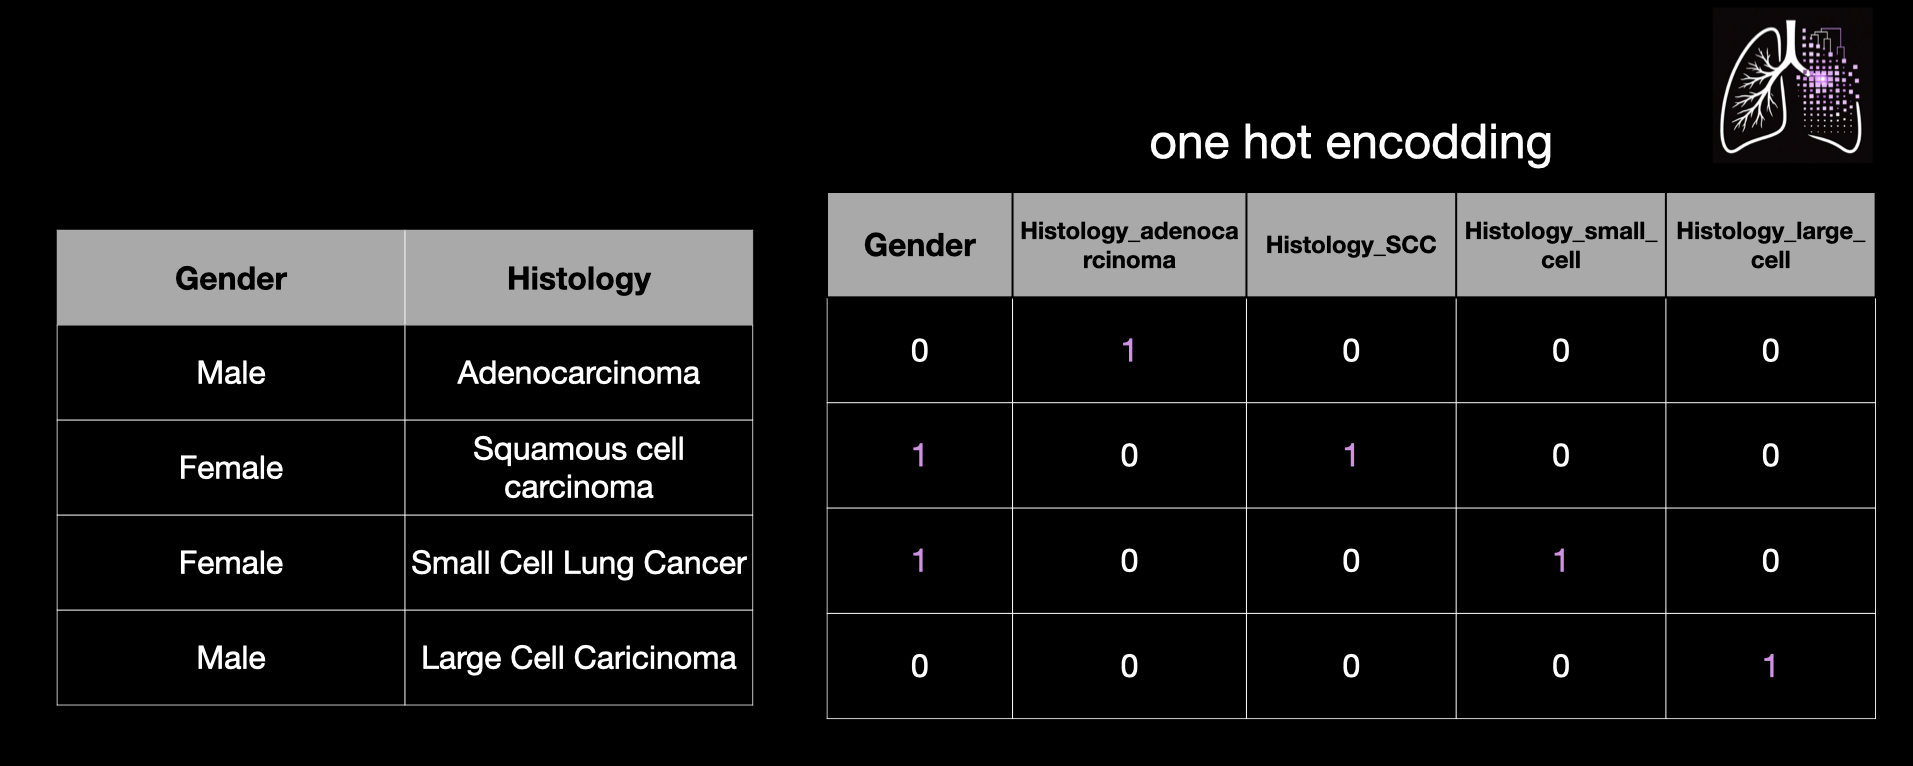

In [ ]:

def categoricalEncoder (dataframe):

    df_categories =pd.DataFrame()
    features_names = []

    for i in range (len (dataframe.columns)):
        instances = dataframe.loc[:, dataframe.columns[i]].unique()

        for j in range (len (instances)):
            new_name ='{}_{}'.format (dataframe.columns[i],instances[j])
            df_categories[new_name ]= np.where(dataframe.iloc[:,i ]== instances [j], 1.0 , 0.0 )
            features_names.append (new_name )

    df_categories.columns = features_names
    return (df_categories )

In [ ]:
df_cat_encod = categoricalEncoder(df_categorical)
df_cat_encod.columns

In [ ]:
df_cat_encod.head(3)

In [ ]:
df_cat_encod = df_cat_encod .drop (columns =['Patient affiliation_VA','Gender_Male','Smoking status_Former','Smoking status_Current'])

In [ ]:
df_cat_encod.head()

## Numerical variables

In [ ]:
df_numerical['Weight (lbs)'] = df_numerical['Weight (lbs)'].replace ("Not Collected", np.nan )

imputer_median = SimpleImputer (strategy ="median")
df_numerical [['Weight (lbs)']] = imputer_median.fit_transform (df_numerical [['Weight (lbs)']])

In [ ]:
df_numerical.head(5)

### Radiomics features redundantes

In [ ]:
df_radiomics_features.shape

In [ ]:
threshold = 0.5

quasi_constant_cols =[]
summary =[]

for col in df_radiomics_features.columns:
    freq = df_radiomics_features[col ].value_counts (dropna = False, normalize =True)
    top_value =freq.index[0]
    top_freq =freq.iloc[0]

    if top_freq >=threshold:
        quasi_constant_cols.append(col)

    summary.append ({"column":col ,
    "most_frequent_value":top_value ,
    "frequency":top_freq ,
    "n_unique":df_radiomics_features [col ].nunique (dropna =False ) })

summary_df = pd.DataFrame (summary ).sort_values("frequency", ascending = False )

print ("Columns with dominant value >=",threshold )
print ("Number of quasi-constant variables:",len (quasi_constant_cols))
print (quasi_constant_cols)

summary_df.head(10)

In [ ]:
summary_df.iloc[25 :,:].head(10)

In [ ]:
df_radiomics_selected = df_radiomics_features.loc[:,summary_df.column[25:]]
df_radiomics_selected.shape

## Table union

In [ ]:
df_radiomics_total = df_numerical.join (df_radiomics_selected)
df_radiomics_total.head(10)

In [ ]:
df_radiomics_total = df_cat_encod.join(df_radiomics_total)
df_radiomics_total.head (3 )

### We select the variables that make sense for the problem: modeling EGFR mutation
>>* y: EGFR mutation status_Mutant
>>* X: Those that may contribute to the diagnosis. We will remove the variables derived from the histopathological study.

In [ ]:
df_radiomics_selected.columns[0:50]

In [ ]:
## Some variables are eliminated:

features_to_eliminate =['Patient affiliation_Stanford','Histology_Adenocarcinoma','Histology_Squamous cell carcinoma',
'Histology_NSCLC NOS (not otherwise specified)',
'Pathological T stage_T2a','Pathological T stage_T3',
'Pathological T stage_T1b','Pathological T stage_T1a',
'Pathological T stage_Tis','Pathological T stage_T4',
'Pathological T stage_T2b',
'Histopathological Grade_G2 Moderately differentiated',
'Histopathological Grade_Other, Type I: Well to moderately differentiated',
'Histopathological Grade_G3 Poorly differentiated',
'Histopathological Grade_G1 Well differentiated',
'Histopathological Grade_Other, Type II: Moderately to poorly differentiated',
'Lymphovascular invasion_Absent','Lymphovascular invasion_Present','EGFR mutation status_Wildtype','KRAS mutation status_Wildtype',
'KRAS mutation status_Not collected','KRAS mutation status_Unknown','KRAS mutation status_Mutant',
'ALK translocation status_Wildtype','ALK translocation status_Not collected','ALK translocation status_Unknown',
'ALK translocation status_Translocated','Survival Status_Dead','Survival Status_Alive']

In [ ]:
df_radiomics_total = df_radiomics_total.drop (columns = features_to_eliminate)

In [ ]:
df_radiomics_total.shape

In [ ]:
df_radiomics_total.head(3)

In [ ]:
df_radiomics_total.to_excel ('data_radiomics_selected.xlsx',index =False )